## Topic 1: What is Exponentially Weighted Moving Average (EWMA)?

### 1. Introduction

**What is it?**
EWMA (also called Exponential Weighted Average) is a technique used to find **trends** in **time series data** — data recorded over time, such as:
- Daily temperature of a city
- Stock prices of a company
- Any sequence of data points recorded day by day

**Why is it important?**
- Helps **remove noise** from data so you can see the real trend
- Gives **more weight to recent data** and less weight to older data
- Used in **forecasting** (predicting future values)
- Used in **signal processing**
- Will be used in **Deep Learning optimizers** (like Momentum)

**Real-life use example:**
If you record Delhi's daily temperature for a year, the raw data will be very "noisy" (lots of ups and downs). EWMA helps you draw a smooth curve that shows the actual warming/cooling trend.

---

### 2. Detailed Explanation

#### The Core Idea (Very Simple)

Imagine you want to track the average temperature over time. But instead of giving equal importance to all days, you decide:

> **"Today's reading is more important than yesterday's, which is more important than last week's."**

That's exactly what EWMA does.

#### Two Key Principles (Must Remember)

| Principle | What it means |
|-----------|----------------|
| **Later points get more weight** | Today's temperature matters more than yesterday's |
| **Weight decreases over time** | A data point from 10 days ago gets very little weight; from 100 days ago gets almost none |

> Think of it like memory fading — the older the memory, the less it affects your current thinking.

#### Mathematical Formula

**Vₜ = β × Vₜ₋₁ + (1 − β) × θₜ**

Where:

| Symbol | Meaning |
|--------|---------|
| **Vₜ** | EWMA at current time "t" (what we are calculating) |
| **β (beta)** | A smoothing parameter between 0 and 1 (e.g., 0.9) |
| **Vₜ₋₁** | EWMA from previous timestamp |
| **θₜ** | Actual data value at current time "t" |

> **Note:** Some sources set V₀ = 0 (initial value). Others use V₀ = θ₁ (first data point). Both are acceptable.

#### Step-by-Step Calculation Example

Suppose we have temperature data: θ₁ = 1.3, θ₂ = something, etc.

**Step 1:** Start with V₀ = 0  
**Step 2:** V₁ = β × V₀ + (1 − β) × θ₁ = 0 + (1−β) × 1.3  
**Step 3:** V₂ = β × V₁ + (1 − β) × θ₂  
**Step 4:** Continue for V₃, V₄, ... until the end

Then connect these V values — you get your smooth EWMA curve.

---

### 3. Key Points

- ✅ EWMA finds the **trend** in time series data
- ✅ Older data points get **exponentially smaller weights** (hence "exponential")
- ✅ The **β (beta)** controls how much weight is given to past data
- ✅ EWMA is used before learning about Deep Learning optimizers like Momentum
- ✅ It smoothens noisy data to reveal the underlying pattern

---

### 7. Common Mistakes

| Mistake | Why it's wrong | How to fix |
|---------|----------------|------------|
| Thinking all points get equal weight | EWMA intentionally gives more weight to recent points | Remember: "later = more weight" |
| Forgetting the initial V₀ value | Different starting values give different curves | Check which convention your resource uses (0 or first data point) |
| Confusing β with weight of current point | Actually (1−β) is the weight of current point | Current weight = 1−β ; Past weight = β |

---

### 8. Interview / Exam Questions

**Q1:** What is Exponentially Weighted Moving Average?  
**A:** A technique to find trends in time series data by giving exponentially decreasing weight to older observations.

**Q2:** Why do we use EWMA instead of a simple average?  
**A:** Simple average gives equal weight to all points. EWMA gives more importance to recent data, which is better for detecting current trends.

**Q3:** What does β represent in the formula Vₜ = β·Vₜ₋₁ + (1−β)·θₜ?  
**A:** β controls how much weight is given to past averages. Higher β = more influence from past data.

---

### 9. Revision Notes

- **EWMA** = Smoothing technique for time series data
- **Formula:** Vₜ = β·Vₜ₋₁ + (1−β)·θₜ
- **Key property:** Recent points have higher weight; older points have exponentially decaying weight
- **Use case:** Remove noise, find trends, prepare for Deep Learning optimizers
- **β value** → determines "memory" of the average

---



## Topic 2: Understanding Beta (β) — The Smoothing Parameter

### 1. Introduction

**What is Beta?**
Beta (β) is a **number between 0 and 1** that controls how much "memory" your EWMA has. It decides whether your average responds quickly to new data or stays smooth by remembering old data.

**Why is it important?**
- Beta is the **only setting you control** in EWMA
- Choosing the right beta completely changes your trend line
- In Deep Learning, optimizing beta helps algorithms learn better
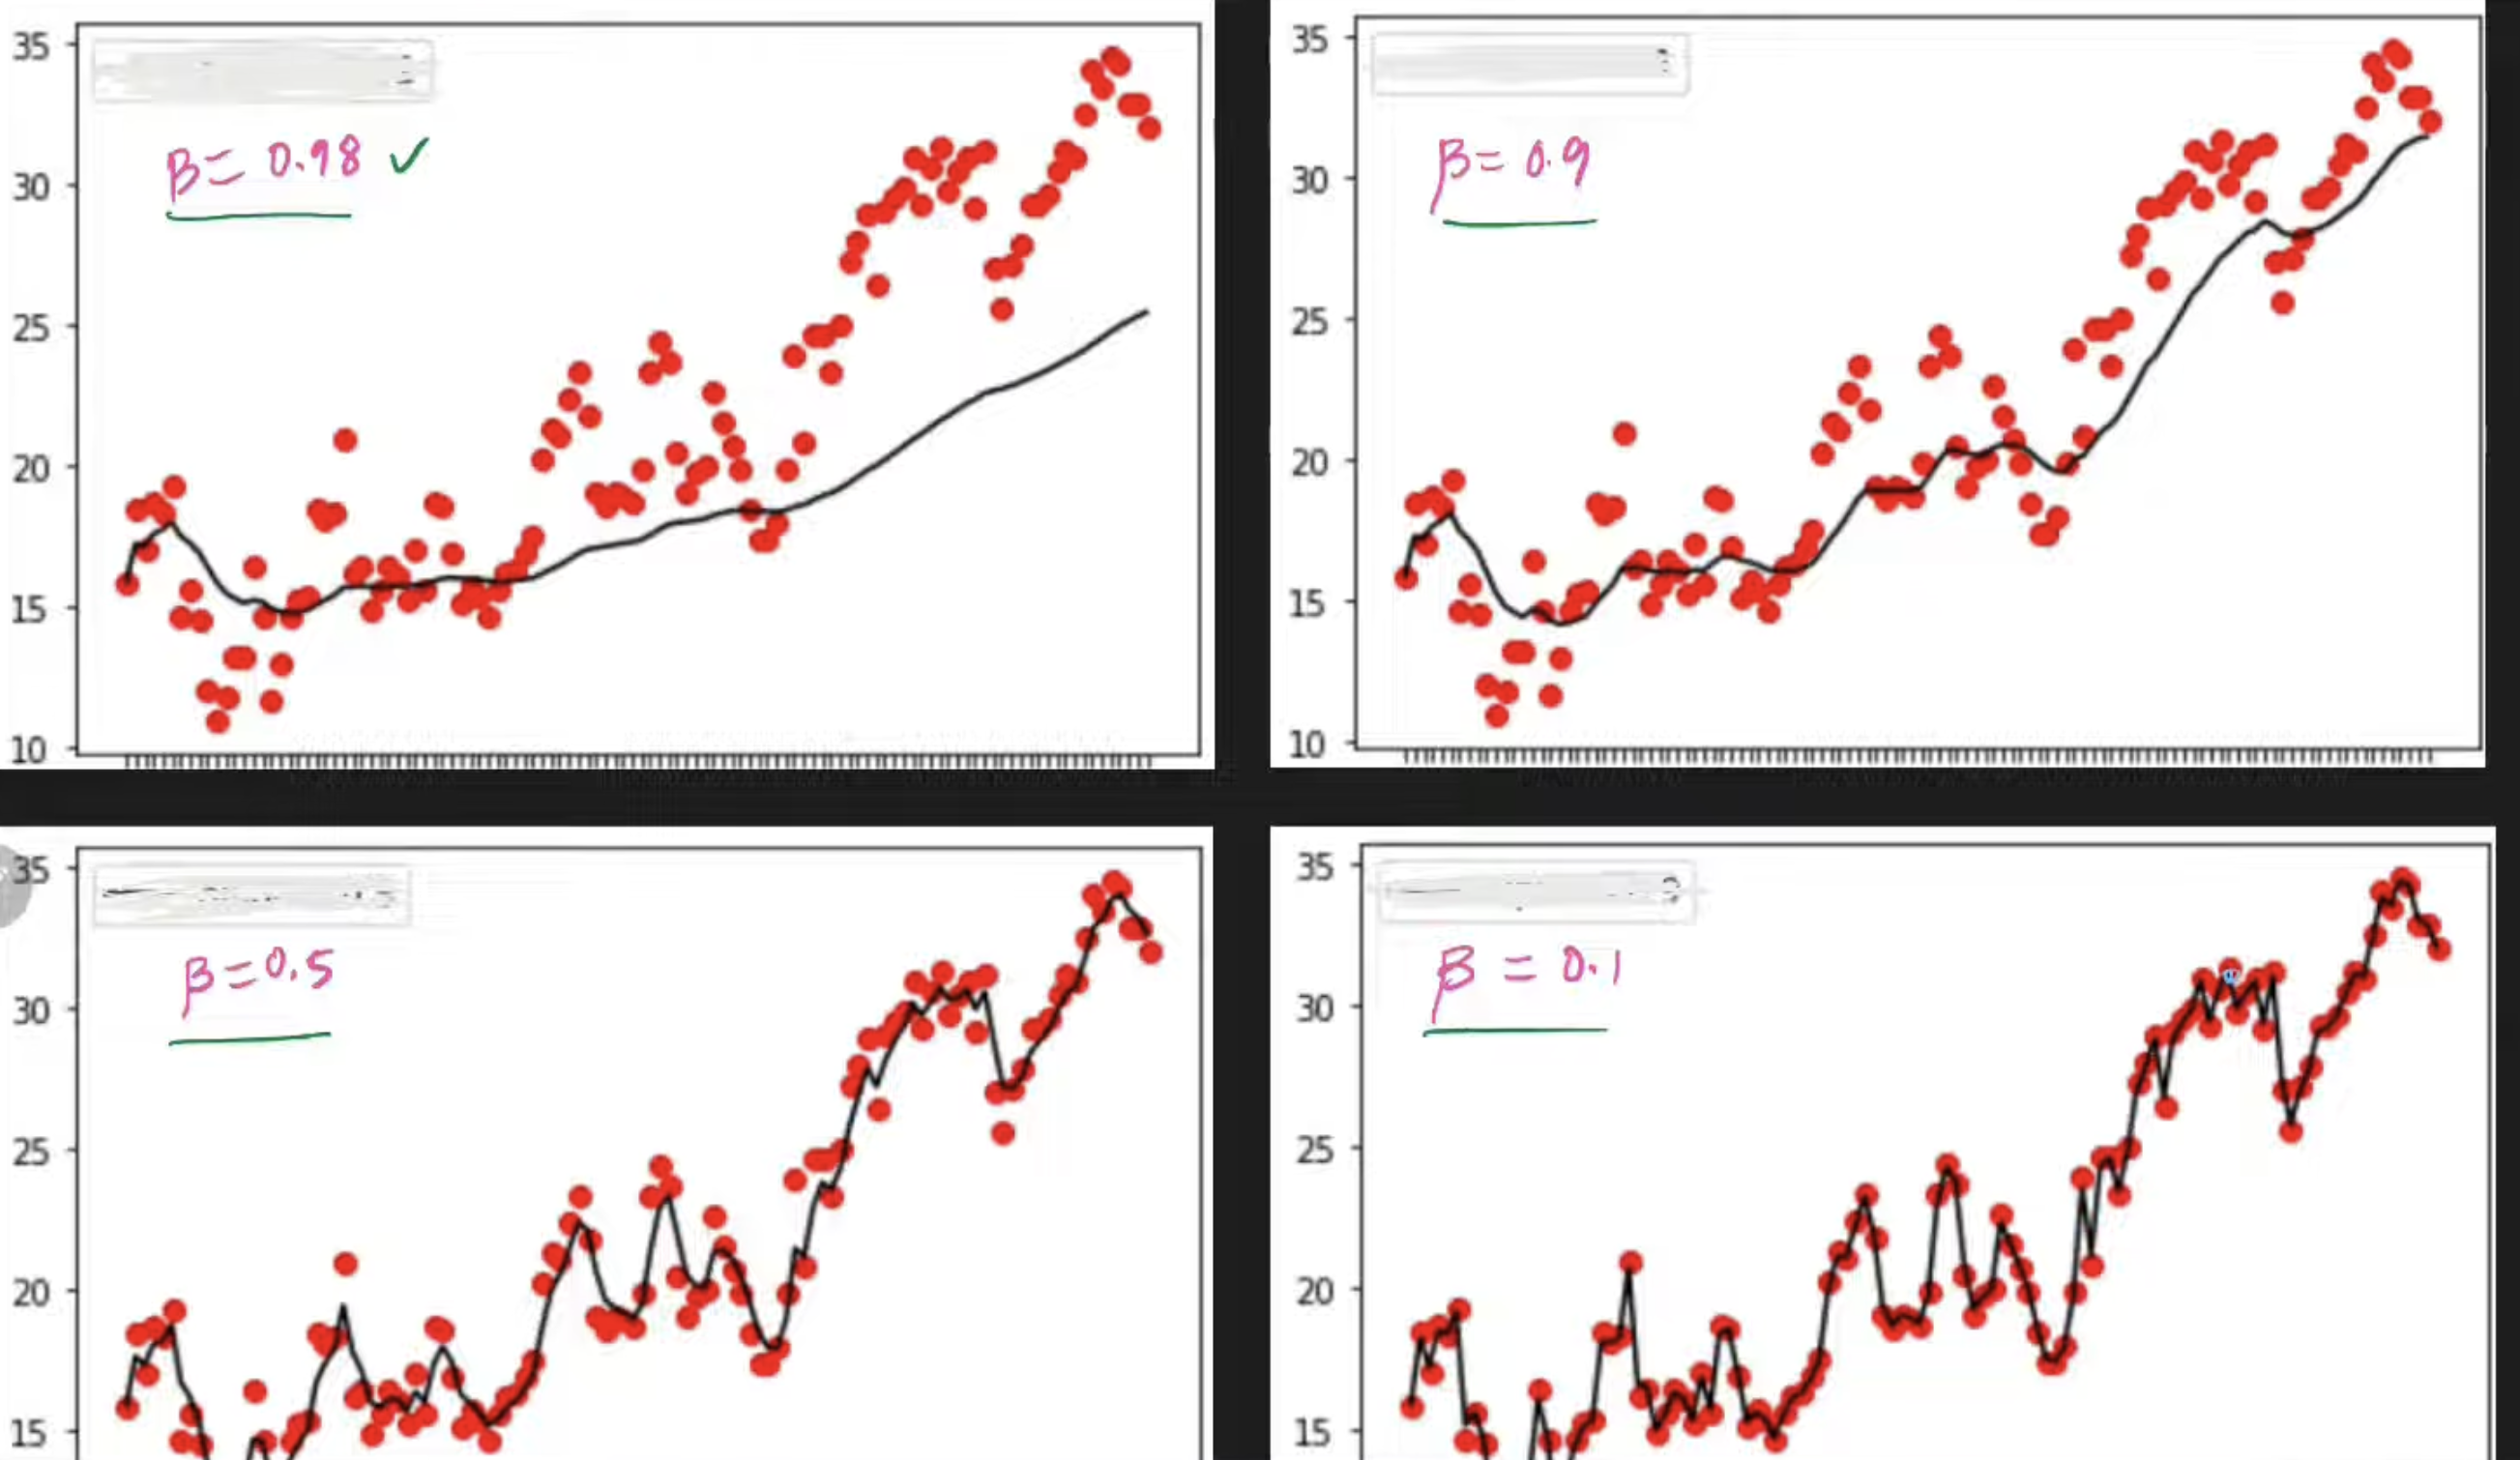
**Real-life analogy:**
Think of beta as **how moody or stable a person is**:

| Beta value | Personality | Behavior |
|------------|-------------|----------|
| **High β (0.98)** | Very stable, hard to influence | Ignores daily ups and downs; changes slowly |
| **Low β (0.1)** | Very moody, reacts instantly | Jumps with every new piece of information |

---

### 2. Detailed Explanation
<embed src="./2_ExponentailWeightedMovingAverage.pdf" type="application/pdf" width="100%" height=600px>

#### The Intuition Behind Beta

Remember the formula: **Vₜ = β × Vₜ₋₁ + (1−β) × θₜ**

Let's break down what beta actually does:

> **Beta = weight given to past average**  
> **(1 − Beta) = weight given to current data point**

| Beta value | Weight on past | Weight on current | What happens |
|------------|---------------|-------------------|--------------|
| 0.9 | 90% | 10% | Very smooth, slow to change |
| 0.5 | 50% | 50% | Equal importance to past and present |
| 0.1 | 10% | 90% | Very reactive, follows noise |

#### Special Case: Beta = 0.5

If β = 0.5, then (1−β) = 0.5

This means: **Vₜ = 0.5 × Vₜ₋₁ + 0.5 × θₜ**

This behaves like a **simple normal average** of all previous days!

#### What Happens When You Change Beta?

**High Beta (close to 1, e.g., 0.98):**
- Past points get **high weight**
- Graph stays **close to the original data trend**
- Very smooth, less reactive
- Good for seeing long-term trends

**Medium Beta (e.g., 0.5):**
- Acts like a normal average
- Middle level of smoothness

**Low Beta (close to 0, e.g., 0.1):**
- Current points get **high weight**
- Graph follows the data **very closely** (includes noise)
- Very reactive, not smooth
- Almost like no averaging at all

#### Visualizing the Effect (Graph Patterns)

Imagine plotting the same temperature data with different beta values:

| Beta | Graph appearance |
|------|------------------|
| 0.98 | Very smooth line, lags behind sudden changes |
| 0.9 | Smooth, clear trend |
| 0.5 | Moderately smooth |
| 0.1 | Almost identical to raw noisy data |

> **Key insight:** As beta decreases, your graph becomes more "attached" to the current data points.

---

### 3. Key Points

- ✅ **Higher β** → More weight to past → Smoother curve → Slower reaction
- ✅ **Lower β** → More weight to present → More reactive → More noise
- ✅ β = 0.5 gives behavior of a **simple average**
- ✅ β is always between **0 and 1**
- ✅ There is a **"sweet spot"** β value for each problem — finding it is part of optimization

---

### 4. Beta vs. Alpha (Important Note!)

In some Python libraries (like Pandas), you might see **α (alpha)** instead of β.

**The relationship is:**  
**α = 1 − β**

So if someone says "alpha = 0.1", that means β = 0.9

| β | α = 1−β |
|---|----------|
| 0.9 | 0.1 |
| 0.5 | 0.5 |
| 0.1 | 0.9 |

Don't get confused — they are just two ways of saying the same thing!

---

### 7. Common Mistakes

| Mistake | Explanation | Fix |
|---------|-------------|-----|
| Thinking higher β means more reactive | Actually HIGHER β = MORE PAST WEIGHT = less reactive | Remember: β = "memory" — more memory = slower change |
| Confusing β with (1−β) | Mixing up which one weights the current point | Current point weight = (1−β) ; Past weight = β |
| Setting β outside 0–1 | Beta must be between 0 and 1 | Always keep 0 ≤ β ≤ 1 |

---

### 8. Interview / Exam Questions

**Q1:** What happens if you set β = 0.99 versus β = 0.5?

**A:** β = 0.99 gives 99% weight to past average — very smooth, slow to react. β = 0.5 gives equal weight (50/50) — behaves like a normal average.

**Q2:** If you want your EWMA to react quickly to sudden changes, should you increase or decrease β?

**A:** DECREASE β. Lower β gives more weight to the current data point, making the average react faster.

**Q3:** What is the relationship between β and α?

**A:** α = 1 − β. They are complementary parameters.

**Q4:** When would you use a very high β (like 0.98)?

**A:** When you want to see the long-term trend by ignoring daily fluctuations — for example, tracking yearly climate change rather than daily weather.

---

### 9. Revision Notes

| β value | Past weight | Current weight | Behavior |
|---------|-------------|----------------|----------|
| Close to 1 | High | Low | Smooth, slow, long memory |
| 0.5 | 50% | 50% | Normal average |
| Close to 0 | Low | High | Reactive, noisy, short memory |

**Formula to remember:**  
- Vₜ = β·Vₜ₋₁ + (1−β)·θₜ  
- α = 1 − β (alternative notation)

**Beta controls the "forgetting rate"** — high beta = slow forgetting, low beta = fast forgetting.

---


## Topic 3: Mathematical Proof — Why Older Points Get Less Weight

### 1. Introduction

**What is this proof showing?**
It demonstrates mathematically that in EWMA, **older data points automatically receive exponentially smaller weights** than recent points. This is not an accident — it's built directly into the formula.

**Why is this important?**
- It proves EWMA does what it claims: "forgets" old data gradually
- Helps you truly understand *why* the formula works
- Interviewers may ask you to explain this derivation

**Real-life analogy:**
Think of each old data point being multiplied by β each time step — like money losing value every day. A point from 10 days ago gets multiplied by β¹⁰, which becomes very tiny if β < 1.

---

### 2. Detailed Explanation — Step-by-Step Derivation

#### Step 1: Start with the Formula

**Vₜ = β × Vₜ₋₁ + (1−β) × θₜ**

Where:
- Vₜ = current EWMA
- Vₜ₋₁ = previous EWMA
- θₜ = current data point

#### Step 2: Expand Vₜ₋₁

Vₜ₋₁ itself comes from the previous step:

**Vₜ₋₁ = β × Vₜ₋₂ + (1−β) × θₜ₋₁**

Substitute this into the Vₜ formula:

**Vₜ = β × [β × Vₜ₋₂ + (1−β) × θₜ₋₁] + (1−β) × θₜ**

#### Step 3: Simplify

**Vₜ = β² × Vₜ₋₂ + β(1−β) × θₜ₋₁ + (1−β) × θₜ**

#### Step 4: Expand Vₜ₋₂

Vₜ₋₂ = β × Vₜ₋₃ + (1−β) × θₜ₋₂

Substitute again:

**Vₜ = β² × [β × Vₜ₋₃ + (1−β) × θₜ₋₂] + β(1−β) × θₜ₋₁ + (1−β) × θₜ**

**Vₜ = β³ × Vₜ₋₃ + β²(1−β) × θₜ₋₂ + β(1−β) × θₜ₋₁ + (1−β) × θₜ**

#### Step 5: See the Pattern

Continue this expansion. The general pattern becomes:

**Vₜ = (1−β) × [θₜ + β·θₜ₋₁ + β²·θₜ₋₂ + β³·θₜ₋₃ + ...] + βᵗ × V₀**

#### Step 6: The Key Observation — Weights Decrease Exponentially

Look at the coefficients (weights) for each data point:

| Data point | Weight | What happens as time passes |
|------------|--------|----------------------------|
| θₜ (today) | (1−β) | Highest weight |
| θₜ₋₁ (yesterday) | (1−β) × β | Smaller |
| θₜ₋₂ (2 days ago) | (1−β) × β² | Even smaller |
| θₜ₋₃ (3 days ago) | (1−β) × β³ | Very small |
| θₜ₋ₖ (k days ago) | (1−β) × βᵏ | Exponentially tiny |

**Since β < 1, βᵏ gets VERY small as k increases!**

---

### 3. Key Points

- ✅ Each older data point gets multiplied by **β each step back in time**
- ✅ After k steps back, weight = (1−β) × βᵏ
- ✅ Because β < 1, βᵏ → 0 as k → ∞
- ✅ This is **exponential decay** — hence "Exponentially Weighted"
- ✅ The proof shows EWMA automatically gives **more weight to recent points**

---

### 4. Numerical Example to See the Decay

Assume β = 0.9, so (1−β) = 0.1

| Data point | Weight calculation | Weight value |
|------------|-------------------|--------------|
| θₜ | 0.1 | 0.1 (10%) |
| θₜ₋₁ | 0.1 × 0.9 | 0.09 (9%) |
| θₜ₋₂ | 0.1 × 0.9² = 0.1 × 0.81 | 0.081 (8.1%) |
| θₜ₋₃ | 0.1 × 0.9³ = 0.1 × 0.729 | 0.0729 (7.29%) |
| θₜ₋₁₀ | 0.1 × 0.9¹⁰ = 0.1 × 0.348 | 0.0348 (3.48%) |

Notice: After 10 days, the weight drops from 10% to about 3.5% — less than half!

---

### 7. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|------|
| Thinking all weights are equal | EWMA specifically creates exponentially decaying weights | Check the expansion proof — βᵏ term decreases |
| Forgetting the (1−β) factor | Every weight contains (1−β) as a multiplier | All terms start with (1−β) |
| Assuming β=0.9 means 90% weight to current | No — 90% is to PAST average, not to current point | Current point gets only (1−β) = 10% |

---

### 8. Interview / Exam Questions

**Q1:** Prove mathematically that EWMA gives exponentially decreasing weight to older observations.

**A:** Expand the formula recursively. Show that θₜ₋ₖ gets multiplied by (1−β)×βᵏ. Since β<1, βᵏ decays exponentially as k increases.

**Q2:** If β = 0.9, what percentage weight does a data point from 5 days ago receive?

**A:** Weight = (1−β) × β⁵ = 0.1 × 0.9⁵ = 0.1 × 0.59049 = 0.059049 ≈ 5.9%

**Q3:** Does EWMA ever completely forget an old data point?

**A:** No — theoretically, weight never reaches zero, only becomes extremely small. In practice, it becomes negligible.

---

### 9. Revision Notes

**The Expanded Formula:**

> **Vₜ = (1−β)θₜ + (1−β)β·θₜ₋₁ + (1−β)β²·θₜ₋₂ + (1−β)β³·θₜ₋₃ + ... + βᵗ·V₀**

**Key takeaway:** Each step back in time multiplies the weight by β again — exponential decay.

| Term | Coefficient (Weight) |
|------|---------------------|
| θₜ (latest) | (1−β) |
| θₜ₋₁ | (1−β)·β |
| θₜ₋₂ | (1−β)·β² |
| θₜ₋ₖ | (1−β)·βᵏ |

**This is the "exponential" in Exponentially Weighted Moving Average.**

---



## Topic 4: EWMA in Python — Practical Implementation

### 1. Introduction

**What are we doing?**
Implementing EWMA on real temperature data from Delhi using Python. The dataset contains daily climate information with:
- Date column (when the measurement was taken)
- Temperature column (mean temperature on that date)

**Why is this important?**
- Connects the mathematical formula to actual working code
- Shows how to use built-in functions vs. manual calculation
- Prepares you for using EWMA in Deep Learning projects

**Real-life use:**
After this, you can apply EWMA to any time series data — stock prices, weather data, sales figures, or sensor readings.

---

### 2. Detailed Explanation — EWMA in Python

#### The Dataset Structure

| Column | Description |
|--------|-------------|
| Date | The day of the measurement |
| Temperature | Mean temperature in Delhi on that date |

The data is a **time series** — ordered by date from earliest to latest.

#### Two Ways to Calculate EWMA

**Method 1: Using a Built-in Library Function**  
Most Python data libraries have ready-made EWMA functions (e.g., Pandas `ewm()` method)

**Method 2: Manual Calculation**  
Implement the formula yourself — good for understanding and practice

---

### 3. Key Points

- ✅ Time series data needs to be in correct chronological order
- ✅ Built-in functions require parameters (alpha or span)
- ✅ You can calculate EWMA for every day in the dataset
- ✅ Results get stored as a new column
- ✅ Always plot both original data and EWMA to see the smoothing effect

---

### 4. Syntax/Structure — Python EWMA Function

#### Using Pandas `.ewm()` method

```python
# Basic syntax for Exponential Weighted Moving Average in Pandas
df['EWMA_column'] = df['temperature_column'].ewm(alpha=0.1).mean()
```

**Parameter explanation:**

| Parameter | What it means | Example |
|-----------|---------------|---------|
| `alpha` | Smoothing factor = 1−β | alpha=0.1 means β=0.9 |
| Or `span` | Alternative parameter | span = 2/α − 1 |
| Or `com` | Center of mass | com = (1−α)/α |

> **Important:** `alpha` is NOT beta.  
> **alpha = 1 − beta**  
> So if you want β=0.9, use `alpha=0.1`

#### Converting between β and α

| β (our formula) | α (Pandas parameter) |
|-----------------|----------------------|
| 0.9 | 0.1 |
| 0.98 | 0.02 |
| 0.5 | 0.5 |
| 0.1 | 0.9 |

---

### 5. Code Example

#### Example 1: Load data and calculate EWMA

```python
import pandas as pd
import matplotlib.pyplot as plt

# Load the daily temperature dataset
# (Assuming CSV with columns: 'date', 'temperature')
df = pd.read_csv('delhi_temperature.csv')

# Sort by date to ensure correct order (important!)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Calculate EWMA with alpha = 0.1 (which means beta = 0.9)
# This gives moderate smoothing - 90% weight to past
df['EWMA_0.1'] = df['temperature'].ewm(alpha=0.1).mean()

# Calculate another EWMA with alpha = 0.02 (beta = 0.98)
# This gives high smoothing - very slow to change
df['EWMA_0.02'] = df['temperature'].ewm(alpha=0.02).mean()

# View the results
print(df[['date', 'temperature', 'EWMA_0.1', 'EWMA_0.02']].head(10))
```

#### Example 2: Manual EWMA calculation (for understanding)

```python
import pandas as pd
import numpy as np

def manual_ewma(data, beta):
    """
    Calculate EWMA manually using the formula Vt = β*Vt-1 + (1-β)*θt
    
    Parameters:
    data: list or array of temperature values
    beta: smoothing parameter (between 0 and 1)
    
    Returns:
    list of EWMA values
    """
    ewma_values = []
    
    # Start with first data point as initial value
    V_prev = data[0]  # V₀ = θ₁
    
    for theta in data:
        # Apply the formula: Vt = β*Vt-1 + (1-β)*θt
        V_current = beta * V_prev + (1 - beta) * theta
        ewma_values.append(V_current)
        V_prev = V_current  # Update for next iteration
    
    return ewma_values

# Example usage
temperatures = [15.9, 15.8, 15.7, 16.2, 16.5, 17.1, 17.4]
beta = 0.9

my_ewma = manual_ewma(temperatures, beta)
print("Manual EWMA:", my_ewma)
```

#### Example 3: Plotting the results

```python
import matplotlib.pyplot as plt

# Assuming df has 'temperature', 'EWMA_0.1', 'EWMA_0.02' columns
plt.figure(figsize=(12, 6))

# Plot original noisy data
plt.plot(df['date'], df['temperature'], 
         label='Original Temperature', 
         alpha=0.5, color='gray')

# Plot EWMA with alpha=0.1 (moderate smoothing)
plt.plot(df['date'], df['EWMA_0.1'], 
         label='EWMA (α=0.1, β=0.9)', 
         color='red', linewidth=2)

# Plot EWMA with alpha=0.02 (high smoothing)
plt.plot(df['date'], df['EWMA_0.02'], 
         label='EWMA (α=0.02, β=0.98)', 
         color='blue', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Delhi Daily Temperature - EWMA Smoothing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

---

### 6. Output — Explanation

When you run the code, you'll see:

**Printed output (first few rows):**

| date | temperature | EWMA_0.1 | EWMA_0.02 |
|------|-------------|----------|-----------|
| 2012-01-01 | 15.9 | 15.90 | 15.90 |
| 2012-01-02 | 15.8 | 15.89 | 15.90 |
| 2012-01-03 | 15.7 | 15.87 | 15.90 |
| 2012-01-04 | 16.2 | 15.90 | 15.91 |
| ... | ... | ... | ... |

**What the numbers show:**
- `EWMA_0.1` changes more quickly because alpha is higher (less past memory)
- `EWMA_0.02` changes very slowly — almost a flat line at first
- Original temperature jumps around; EWMA values are smoother

**Graph interpretation:**
- Gray line (original): Noisy, many ups and downs
- Red line (α=0.1): Follows trend but smooths out small bumps
- Blue line (α=0.02): Very smooth, shows only major long-term changes

---

### 7. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|------|
| Using beta instead of alpha in `.ewm()` | Pandas uses `alpha`, not `beta` | Remember: `alpha = 1 − beta` |
| Not sorting data by date | EWMA assumes correct time order | Always sort by date before calculating |
| Forgetting to convert date column | Pandas may treat dates as strings | Use `pd.to_datetime()` |
| Using `alpha=0.9` when you want β=0.9 | This gives β=0.1 (very reactive!) | If β=0.9 desired, use `alpha=0.1` |
| Not resetting V_prev in manual loop | Each iteration needs previous value | Update `V_prev = V_current` in loop |

---

### 8. Interview / Exam Questions

**Q1:** How do you calculate EWMA in Python using Pandas?

**A:** Use `df['column'].ewm(alpha=value).mean()` where `alpha = 1 − beta`

**Q2:** What is the difference between using a library function vs. manual calculation?

**A:** Library functions are faster, tested, and handle edge cases. Manual calculation helps you understand the formula but is slower for large datasets.

**Q3:** Why must time series data be sorted before applying EWMA?

**A:** EWMA assumes chronological order. If data is unsorted, you'll be averaging future and past points incorrectly.

**Q4:** If you want a very smooth EWMA curve, should you use a higher or lower alpha in Pandas?

**A:** LOWER alpha gives smoother results. Alpha = 0.02 (β=0.98) is very smooth; alpha = 0.5 (β=0.5) is less smooth.

---

### 9. Revision Notes

**Key code pattern:**
```python
# One line EWMA in Pandas
df['ewma'] = df['temperature'].ewm(alpha=0.1).mean()
```

**Beta ↔ Alpha conversion:**
- α = 1 − β
- β = 1 − α

**Workflow:**
1. Load data
2. Convert dates → datetime
3. Sort by date
4. Apply `.ewm(alpha=X).mean()`
5. Plot original vs. EWMA

**Practice suggestion:** Try different alpha values (0.01, 0.05, 0.1, 0.5) and observe how the graph changes.

---


## Topic 5: EWMA in Deep Learning — Optimizers and Momentum

### 1. Introduction

**What is the connection?**
EWMA is not just for weather data or stock prices — it is a **core building block** inside many Deep Learning optimizers, especially **Momentum**-based optimizers.

**Why is this important?**
- Before understanding optimizers like Momentum, RMSprop, or Adam, you **must** understand EWMA
- EWMA helps gradient descent "remember" past gradients and smooth out updates
- This leads to **faster training** and **better convergence**

**Real-life analogy in Deep Learning:**
Imagine you are rolling a ball down a hill toward the minimum point:
- Without EWMA: The ball bounces around chaotically with each small bump
- With EWMA (Momentum): The ball remembers its past direction and keeps rolling smoothly — it doesn't overreact to every tiny bump

---

### 2. Detailed Explanation — Why Deep Learning Uses EWMA

#### The Problem with Standard Gradient Descent

Standard Gradient Descent updates weights using only the **current gradient**. This causes:

| Problem | Effect |
|---------|--------|
| No memory of past directions | Can zig-zag in narrow valleys |
| Sensitive to noisy gradients | Training becomes unstable |
| Slow convergence | Wastes time on unnecessary oscillations |

#### How EWMA Solves This

Deep Learning optimizers use EWMA to track **past gradients**:

> **Updated gradient = β × (previous updated gradient) + (1−β) × (current gradient)**

This is **exactly the same EWMA formula** but applied to gradients instead of temperatures!

| EWMA (generic) | Deep Learning (Momentum) |
|----------------|--------------------------|
| Vₜ = β·Vₜ₋₁ + (1−β)·θₜ | vₜ = β·vₜ₋₁ + (1−β)·∇L(θ) |
| θₜ = current data point | ∇L(θ) = current gradient |
| Vₜ = smoothed average | vₜ = smoothed gradient (velocity) |

#### Where EWMA Appears in Deep Learning

| Optimizer | Uses EWMA on |
|-----------|--------------|
| **Momentum** | Past gradients |
| **RMSprop** | Past squared gradients (adaptive learning rate) |
| **Adam** | Both: past gradients AND past squared gradients |
| **Nadam** | Adam + Nesterov momentum |

---

### 3. Key Points

- ✅ EWMA is **not just for data smoothing** — it's a core mathematical tool in Deep Learning
- ✅ Momentum optimizers use EWMA to give **gradients a "memory"**
- ✅ The same β parameter controls how much past gradients influence the current update
- ✅ You must understand EWMA **before** studying Momentum, RMSprop, or Adam
- ✅ Many interview questions about optimizers assume you know EWMA

---

### 4. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|------|
| Thinking EWMA is only for data preprocessing | It's also inside optimizers | Understand EWMA as a general smoothing technique |
| Confusing the two different uses | Weather data vs. gradient smoothing | The formula is identical — the application is different |
| Learning optimizers without knowing EWMA | You won't truly understand how they work | Master EWMA first, then study Momentum |

---

### 8. Interview / Exam Questions

**Q1:** Why is EWMA used in Deep Learning optimizers?

**A:** EWMA smooths out noisy gradients by giving more weight to recent gradients while gradually forgetting old ones. This reduces oscillations and speeds up convergence.

**Q2:** Which optimizers use EWMA internally?

**A:** Momentum, RMSprop, Adam, Nadam, and many others.

**Q3:** How does the β parameter behave differently in Momentum vs. standard EWMA?

**A:** The mathematical behavior is identical — higher β means more influence from past gradients (smoother updates), lower β means more reactive to current gradients.

**Q4:** Why can't we just use a simple average of past gradients instead of EWMA?

**A:** Simple average gives equal weight to all past gradients, including very old ones. EWMA gradually forgets old gradients, which is better because recent gradient direction is more relevant.

---

### 9. Revision Notes

**The Big Picture:**

```
EWMA (generic) → Used in Deep Learning Optimizers → Enables faster/better training
                        ↓
              ┌─────────┼─────────┐
              ↓         ↓         ↓
          Momentum   RMSprop    Adam
```

**Formula in Deep Learning context:**
> **vₜ = β·vₜ₋₁ + (1−β)·gₜ**

Where:
- vₜ = smoothed gradient (velocity)
- gₜ = current gradient at time t
- β = momentum parameter (usually 0.9)

**Next steps after this lesson:**
1. Study the Momentum optimizer
2. Study RMSprop (uses EWMA on squared gradients)
3. Study Adam (combines both)
4. Implement these optimizers from scratch

---

### Complete Topic Summary — EWMA (All 5 Topics)

| Topic | Core takeaway |
|-------|---------------|
| 1. What is EWMA | Smoothing technique for time series data |
| 2. Beta (β) | Controls memory: high β = smooth, low β = reactive |
| 3. Mathematical proof | Older points get exponentially smaller weights: βᵏ |
| 4. Python implementation | `.ewm(alpha=1−β).mean()` |
| 5. Deep Learning use | Core of Momentum, RMSprop, Adam optimizers |

---

**You have now completed all topics from the transcript.** 

